##### Ipl Data Analysics Project









# Loading the dataset

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("C:/Users/MURARI SINGH/Downloads/IPL.csv")
df.head()


,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22


# Basic information

# df.info()

# SIZE OF THE DATA IN ROW AND COLUMN


In [24]:
print(f"your rows are {df.shape[0]} and your column are{df.shape[1]}")

your rows are 74 and your column are20


# how many column have null values


In [18]:
df.isnull().sum()

match_id               0
date                   0
venue                  0
team1                  0
team2                  0
stage                  0
toss_winner            0
toss_decision          0
first_ings_score       0
first_ings_wkts        0
second_ings_score      0
second_ings_wkts       0
match_winner           0
won_by                 0
margin                 0
player_of_the_match    0
top_scorer             0
highscore              0
best_bowling           0
best_bowling_figure    0
dtype: int64

# 1. which team on the most matches

Text(0.5, 1.0, 'most match winner')

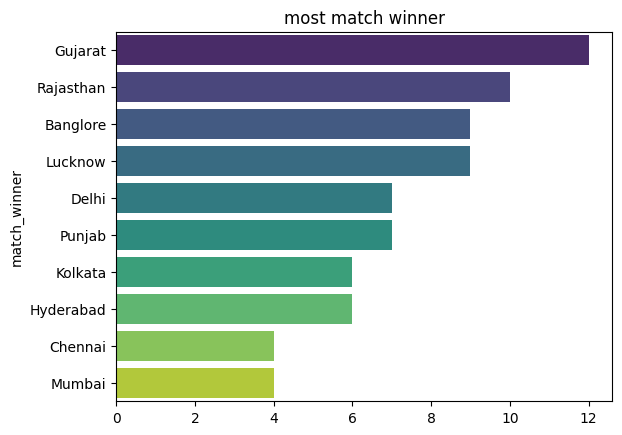

In [31]:
match_wins = df['match_winner'].value_counts()
sns.barplot(y = match_wins.index , x = match_wins.values , palette ='viridis')
plt.title("most match winner")

## 2. toss decision trend

Text(0.5, 1.0, 'toss_decision_trend')

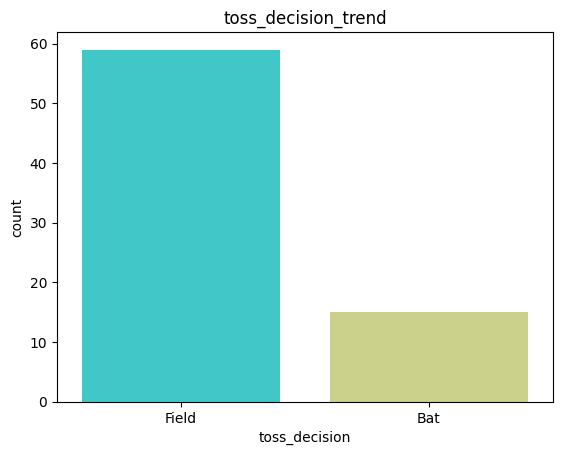

In [37]:
sns.countplot( x = df['toss_decision'],palette = 'rainbow')
plt.title("toss_decision_trend")

### 3. toss winner vs match winners

In [44]:
count = df[df['toss_winner'] == df['match_winner']]['match_id'].count()
percentege = count * 100 / df.shape[0]
percentege.round(2)

np.float64(48.65)

#### 4. won by runus ya wickets

<Axes: xlabel='won_by', ylabel='count'>

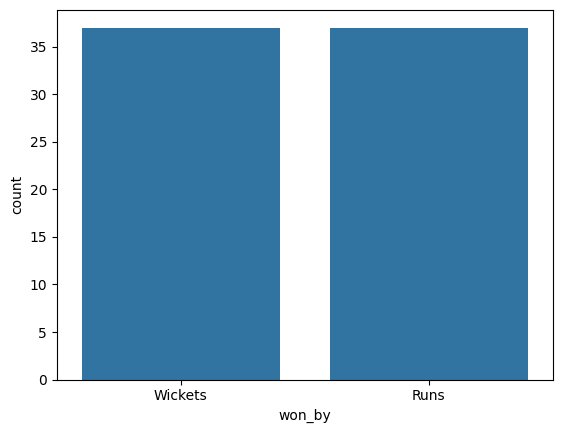

In [45]:
sns.countplot(x = df['won_by'])

# Key player performance


# 1. Most  player won the mam of match award


Text(0.5, 1.0, 'man of the match ')

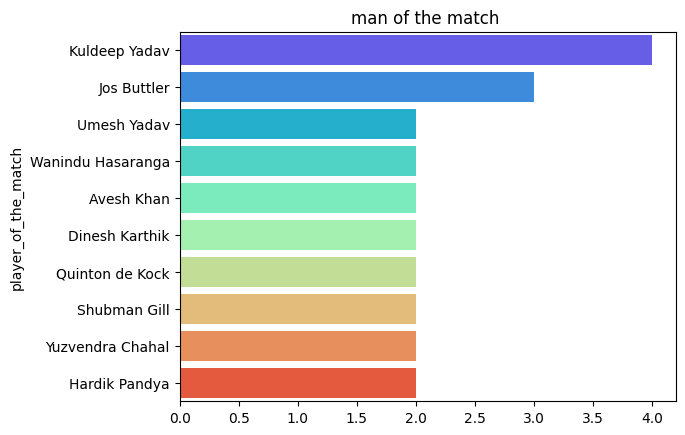

In [50]:
count  = df['player_of_the_match'].value_counts().head(10)
count
sns.barplot(x= count.values , y = count.index , palette = 'rainbow')
plt.title("man of the match ")

## 2. Top scorere

In [54]:
high = df.groupby('top_scorer')['highscore'].sum().sort_values(ascending=False).head(5)
high

top_scorer
Jos Buttler        651
Quinton de Kock    377
KL Rahul           351
Shubman Gill       288
Faf du Plessis     257
Name: highscore, dtype: int64

<Axes: xlabel='top_scorer'>

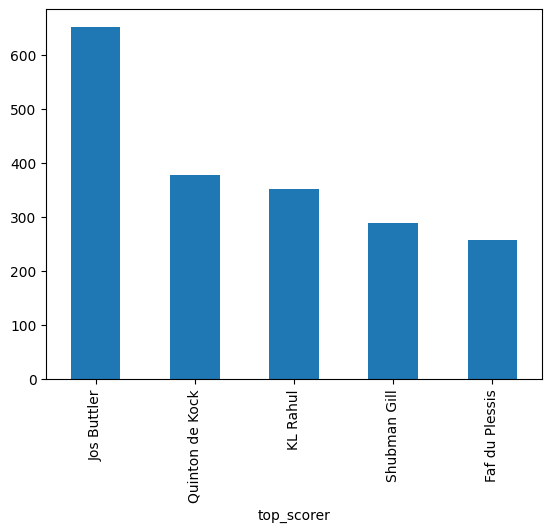

In [55]:
high.plot(kind = 'bar')

### 10 Bolwwing figure

<Axes: ylabel='best_bowling'>

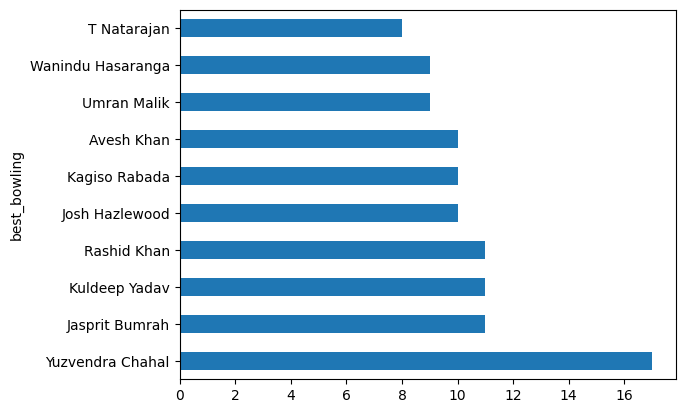

In [62]:
df['highest_wickets'] = df['best_bowling_figure'].apply(lambda x :x.split('--')[0])
df['highest_wickets'] = df['highest_wickets'].astype(int)
top_bowlers = df.groupby('best_bowling')['highest_wickets'].sum().sort_values(ascending=False).head(10)
top_bowlers.plot(kind = 'barh')

# VEANU ANALYSISC

# Most Match Played By Veanu 

In [64]:
venue_count = df['venue'].value_counts()
venue_count

venue
Wankhede Stadium, Mumbai                        21
Dr DY Patil Sports Academy, Mumbai              20
Brabourne Stadium, Mumbai                       16
Maharashtra Cricket Association Stadium,Pune    13
Eden Gardens, Kolkata                            2
Narendra Modi Stadium, Ahmedabad                 2
Name: count, dtype: int64

<Axes: ylabel='venue'>

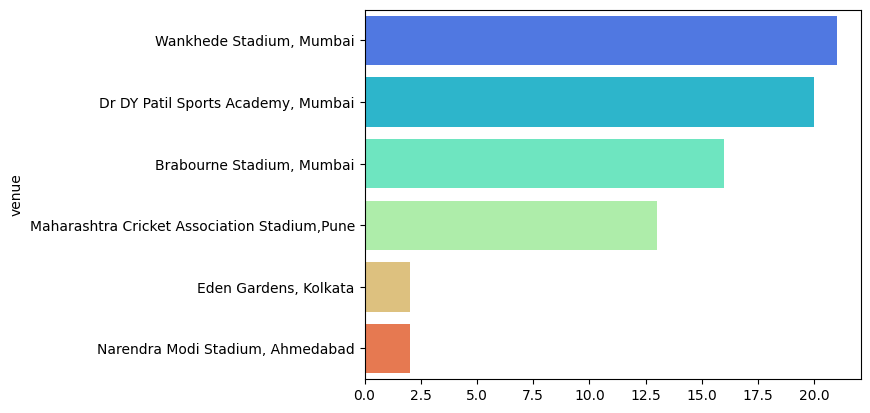

In [66]:
sns.barplot(y = venue_count.index , x = venue_count.values, palette='rainbow')

# Custom Question & inshights

# q1= who won the highest margin by runs

In [75]:
df[df['won_by'] == 'Runs'].sort_values(by = 'margin',ascending=False).head(1)[['match_winner','margin']]

,match_winner,margin
54,Chennai,91


 Q2. which player had the highest indivisual score 

In [76]:
df[df['highscore'] == df['highscore'].max()][['top_scorer','highscore']]

,top_scorer,highscore
65,Quinton de Kock,140


In [79]:
df[df['highest_wickets'] == df['highest_wickets'].max()][['best_bowling','best_bowling_figure']]

,best_bowling,best_bowling_figure
29,Yuzvendra Chahal,5--40
39,Umran Malik,5--25
53,Wanindu Hasaranga,5--18
55,Jasprit Bumrah,5--10
